# Beta Hedging

#### Factor Models

Factor models are a way of explaining the returns of one asset via a linear combination of the returns of other assets. The general form of a factor model is:

$$
Y = \alpha + \beta_1 X_1 + \beta_2 X_2 + \cdots + \beta_n X_n
$$

This looks familiar, as it is exactly the model type that a linear regression fits. The $X$s can also be indicators rather than assets. An example might be analyst estimations.

**What is an asset's Beta to another asset?**  

It is just the $\beta$ from the above model. For instance, if we regressed TSLA against the S&P 500 using the model $Y_{TSLA} = \alpha + \beta X_{SPY}$, then TSLA's beta exposure to the S&P 500 would be that $\beta$. If we used the model $Y_{TSLA} = \alpha + \beta_{SPY} X_{SPY} + \beta_{AAPL} X_{AAPL}$, then we now have two betas: one is TSLA's exposure to the S&P 500 and one is TSLA's exposure to AAPL.

Often "beta" refers to a stock's beta exposure to the S&P 500. We will use it to mean that unless otherwise specified.

In [11]:
import numpy as np
import pandas as pd
import yfinance as yf
import math
import statsmodels.api as sm
from statsmodels import regression
from matplotlib import pyplot as plt

Get the data for SPY and TSLA

/var/folders/5v/9xrz7nmd29s2z029pvbqs8r00000gn/T/ipykernel_30288/604823524.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  asset = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/var/folders/5v/9xrz7nmd29s2z029pvbqs8r00000gn/T/ipykernel_30288/604823524.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  index_data = yf.download(index, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


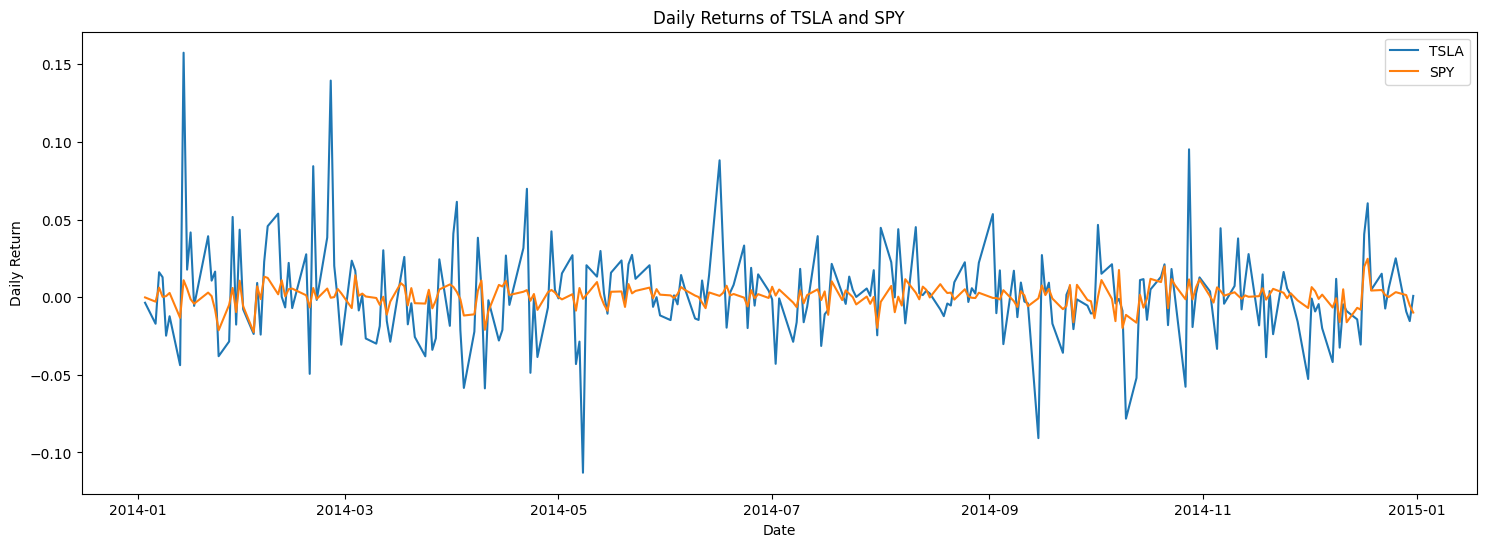

Mean of TSLA returns: 0.0020
Standard Deviation of TSLA returns: 0.0305
Mean of SPY returns: 0.0006
Standard Deviation of SPY returns: 0.0071


In [12]:
start_date = '2014-01-01'
end_date = '2015-01-01'
ticker = 'TSLA'
index = 'SPY'

asset = yf.download(ticker, start=start_date, end=end_date)
index_data = yf.download(index, start=start_date, end=end_date)

# Compute and plot their returns on the same graph
asset_returns = asset['Close'].pct_change().dropna()
index_returns = index_data['Close'].pct_change().dropna()

plt.figure(figsize=(18, 6))
plt.plot(asset_returns.index, asset_returns, label=ticker)
plt.plot(index_returns.index, index_returns, label=index)
plt.title('Daily Returns of {} and {}'.format(ticker, index))
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.legend()
plt.show()

# Display the mean and standard deviation of the returns
print("Mean of {} returns: {:.4f}".format(ticker, asset_returns[ticker].mean()))
print("Standard Deviation of {} returns: {:.4f}".format(ticker, asset_returns[ticker].std()))
print("Mean of {} returns: {:.4f}".format(index, index_returns[index].mean()))
print("Standard Deviation of {} returns: {:.4f}".format(index, index_returns[index].std()))

Let us now run the regression to find $\alpha$ and $\beta$

In [13]:
Y = asset_returns.values
X = index_returns.values

def linregression(x, y):
  x = sm.add_constant(x)
  model = sm.OLS(y, x).fit()
  # remove the constant term and return the slope and intercept
  x = x[:, 1]
  return model.params[1], model.params[0]

beta, alpha = linregression(X, Y)
print("Beta:", beta)
print("Alpha:", alpha)

Beta: 1.954157540707684
Alpha: 0.0009171532707482784


Now let us plot the line of best fit and see how well it is able to fit the data sample

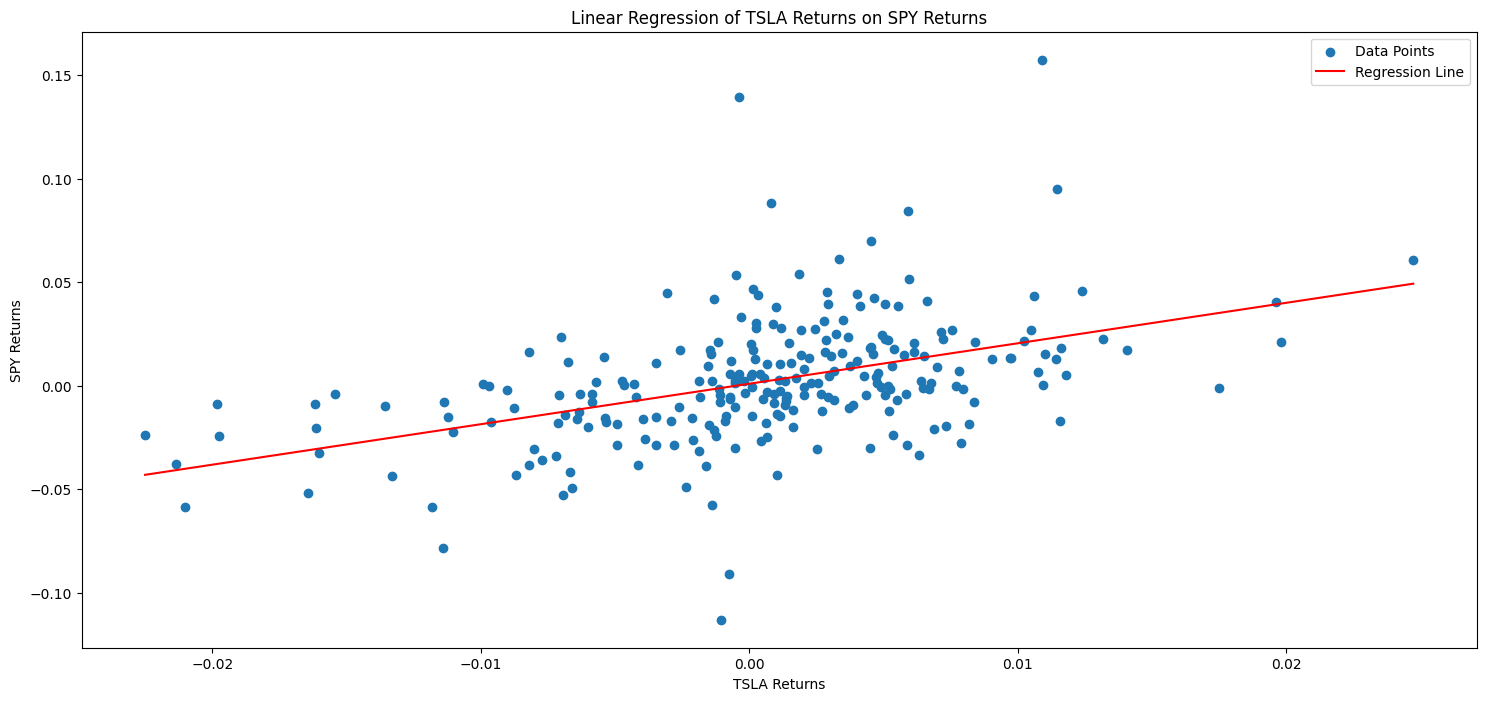

In [14]:
X2 = np.linspace(X.min(), X.max(), 100)
y_hat = X2 * beta + alpha

# Plot the scatter plot of the returns and the regression line
plt.figure(figsize=(18, 8))
plt.scatter(X, Y, label='Data Points')
plt.plot(X2, y_hat, color='red', label='Regression Line')
plt.title('Linear Regression of {} Returns on {} Returns'.format(ticker, index))
plt.xlabel('{} Returns'.format(ticker))
plt.ylabel('{} Returns'.format(index))
plt.legend()
plt.show()

#### Risk Exposure

More generally, an asset has a high **beta** to the S&P 500, then while the market is rising, it will do very well. If an asset has a high beta, it corresponds to high speculative risk. You are taking on a more volatile bet.

#### Risk Management

The process of reducing exposure to other factors is known as **risk management**. Hedging is one of the best ways to perform risk management in practice.

**Hedging**

If we determine that our portfolio returns are dependent on the market via this relation

$$
Y_{portfolio} = \alpha + \beta X_{SPY}
$$

then we can take out a short position in SPY to try to cancel out this risk. The amount we take out is approximately $-\beta DV$, where $DV$ is the total dollar volume of our portfolio. If we short $-\beta DV$ dollars of SPY, then adding our new returns: $\alpha + \beta X_{SPY} - \beta X_{SPY} = \alpha$. Our returns are now purely **alpha**, which is independent of SPY and will suffer no risk exposure to the market.

**Market Neutral**

When a strategy exhibits a consistent beta of 0, we say that this strategy is **market neutral**.

#### Problems with Estimation

The problem here is that the beta we estimated is not necessarily going to stay the same as we walk forward in time. As such, the amount of beta we short out in SPY may not perfectly hedge our portfolio, and in practice it is quite difficult to reduce beta by a significant amount. In short, each estimate has a **standard error** that corresponds to how stable the estimate is within the observed data.

#### Implementing Hedging

Now we know how much to hedge, we shall see how it affects our returns. We will build our oortfolio using the asset and the benchmark, weighing the benchmark by $-\beta$, since we are short in it.

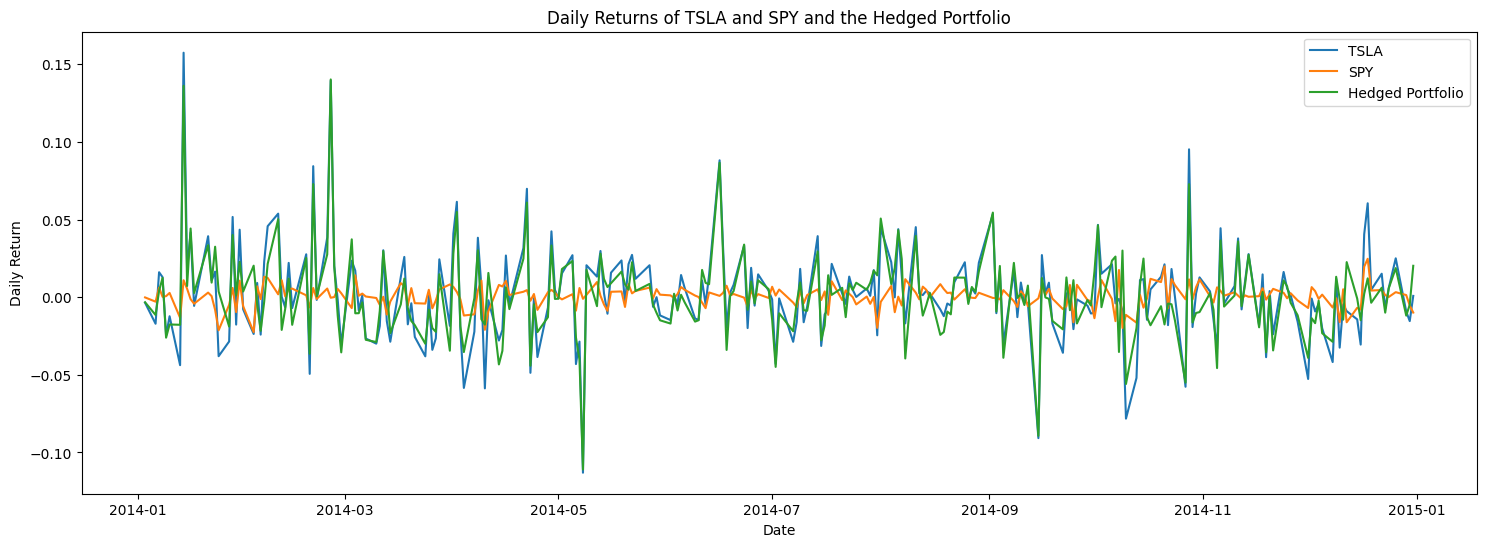

In [25]:
portfolio = -1 * beta * X + Y

# Plot the returns of the portfolio as well as the returns of the asset and index
plt.figure(figsize=(18, 6))
plt.plot(asset_returns.index, asset_returns, label=ticker)
plt.plot(index_returns.index, index_returns, label=index)
plt.plot(index_returns.index, portfolio, label='Hedged Portfolio')
plt.title('Daily Returns of {} and {} and the Hedged Portfolio'.format(ticker, index))
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.legend()
plt.show()

It looks at first glance, the hedged portfolio tracks the returns of the asset quite closely. We can quantify the difference in their performance by computing the mean returns and the volatilities for both.

In [18]:
print("Mean of the hedged portfolio returns: {:.4f}".format(portfolio.mean()))
print("Mean of stock returns: {:.4f}".format(Y.mean()))
print("Standard Deviation of the hedged portfolio returns: {:.4f}".format(portfolio.std()))
print("Standard Deviation of stock returns: {:.4f}".format(Y.std()))

Mean of the hedged portfolio returns: 0.0009
Mean of stock returns: 0.0020
Standard Deviation of the hedged portfolio returns: 0.0271
Standard Deviation of stock returns: 0.0304


We have decreased volatility at the expense of some returns. For that, we can check that the alpha is the same as before, while the beta has been eliminated.

In [20]:
beta, alpha = linregression(X, portfolio)
print("Beta of the hedged portfolio:", beta)
print("Alpha of the hedged portfolio:", alpha)

Beta of the hedged portfolio: 1.5265566588595902e-16
Alpha of the hedged portfolio: 0.0009171532707482779


#### Validity of Hedging Strategy

Now that we have developed the hedging strategy, using the historical data, we can check to see if it is still valid out-of-sample by checking the alpha and beta values of the asset and the hedged portfolip in a different time frame.

In [23]:
start_date = '2014-01-01'
end_date = '2015-01-01'
ticker = 'TSLA'
index = 'SPY'

asset = yf.download(ticker, start=start_date, end=end_date)
index_data = yf.download(index, start=start_date, end=end_date)

# Compute their returns
asset_returns = asset['Close'].pct_change().dropna()
index_returns = index_data['Close'].pct_change().dropna()
X = index_returns.values
Y = asset_returns.values

beta, alpha = linregression(X, Y)

# Get data for a different time period
start_date2 = '2015-01-01'
end_date2 = '2016-01-01'
asset2 = yf.download(ticker, start=start_date2, end=end_date2)
index_data2 = yf.download(index, start=start_date2, end=end_date2)
asset_returns2 = asset2['Close'].pct_change().dropna()
index_returns2 = index_data2['Close'].pct_change().dropna()
X2 = index_returns2.values
Y2 = asset_returns2.values

beta2, alpha2 = linregression(X2, Y2)

# Create the hedged portfolio for the second time period, using the beta from the first time period
portfolio2 = -1 * beta * X2 + Y2
beta3, alpha3 = linregression(X2, portfolio2)

# Store the results in a DataFrame
results = pd.DataFrame({
    'Asset Historical Period': [alpha, beta],
    'Asset Out of Sample Period': [alpha2, beta2],
    'Hedged Portfolio Out of Sample Period': [alpha3, beta3]
}, index=['Alpha', 'Beta'])
results


/var/folders/5v/9xrz7nmd29s2z029pvbqs8r00000gn/T/ipykernel_30288/1186266152.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  asset = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/var/folders/5v/9xrz7nmd29s2z029pvbqs8r00000gn/T/ipykernel_30288/1186266152.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  index_data = yf.download(index, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/var/folders/5v/9xrz7nmd29s2z029pvbqs8r00000gn/T/ipykernel_30288/1186266152.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  asset2 = yf.download(ticker, start=start_date2, end=end_date2)
[*********************100%***********************]  1 of 1 completed
/var/folders/5v/9xrz7nmd29s2z029pvbqs8r00000gn/T/ipykernel_30288/1186266152.py:21: FutureWarning: YF.download() has cha

,Asset Historical Period,Asset Out of Sample Period,Hedged Portfolio Out of Sample Period
Alpha,0.000917,0.000545,0.000545
Beta,1.954158,1.141762,-0.812396


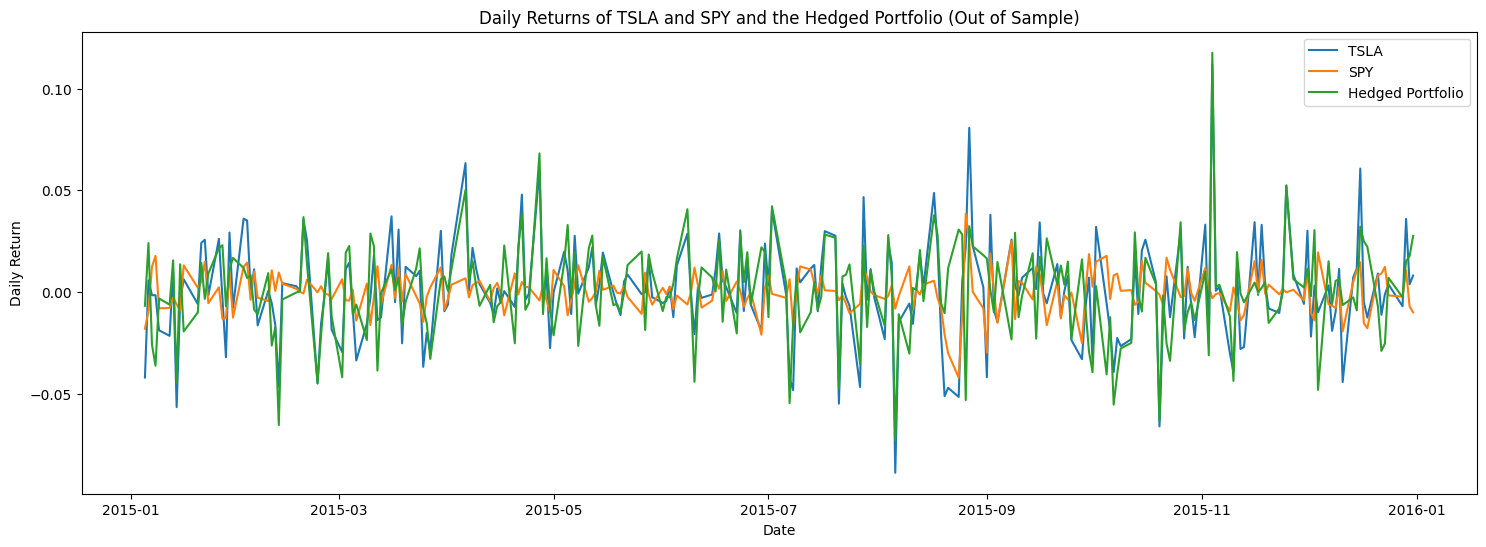

In [26]:
# Plot the returns of the asset and the hedged portfolio for the second time period
plt.figure(figsize=(18, 6))
plt.plot(asset_returns2.index, asset_returns2, label=ticker)
plt.plot(index_returns2.index, index_returns2, label=index)
plt.plot(index_returns2.index, portfolio2, label='Hedged Portfolio')
plt.title('Daily Returns of {} and {} and the Hedged Portfolio (Out of Sample)'.format(ticker, index))
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.legend()
plt.show()